# Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys, os
# sys.path.append(r'../Lib/')
from ionization_shock import *
import qutip as qt
from tqdm import tqdm

In [2]:
transition_matrix = np.array([
[99.83,0.03,0.05,0.00,0.00,0.00,0.00,0.00],
[0.08,99.72,0.07,0.11,0.00,0.00,0.00,0.00],
[0.09,0.08,99.56,0.07,0.14,0.00,0.00,0.00],
[0.00,0.17,0.09,99.51,0.07,0.11,0.00,0.00],
[0.00,0.00,0.23,0.12,99.56,0.09,0.11,0.00],
[0.00,0.00,0.00,0.20,0.07,99.59,0.08,0.05],
[0.00,0.00,0.00,0.00,0.15,0.11,99.69,0.06],
[0.00,0.00,0.00,0.00,0.00,0.00,0.09,99.88],
])

transition_matrix = np.load(r'sims_data/T_est.npy')
transition_matrix = transition_matrix/np.sum(transition_matrix, axis=0)
cdf_matrix = np.cumsum(transition_matrix, axis=0)

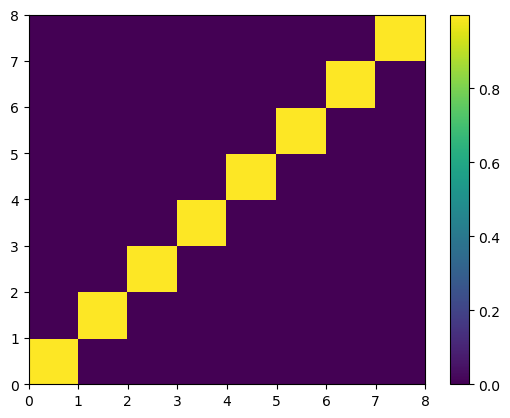

In [3]:
plt.pcolor(transition_matrix)
plt.colorbar()

# Simulate random time trace

In [3]:
current_state = 0
n_steps = 1000
trace = np.zeros(n_steps)

for i in range(n_steps):
    trace[i] = current_state
    probs = transition_matrix[:, current_state]
    current_state = np.random.choice(range(8), p=probs/np.sum(probs))

Text(0, 0.5, 'State')

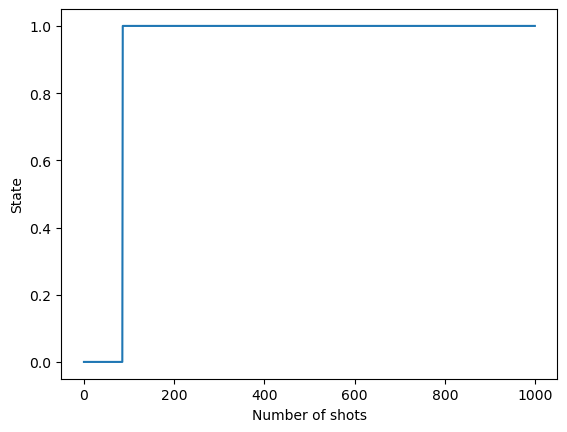

In [4]:
plt.plot(trace)
plt.xlabel('Number of shots')
plt.ylabel('State')

# simulate realistic readout

In [6]:
cfd_matrix = np.cumsum(transition_matrix, axis=0)
qt.Qobj(cfd_matrix)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[9.98750928e-01 5.41337103e-04 5.74346874e-04 1.70322932e-15
  1.40571846e-15 1.70660113e-05 1.75867466e-15 1.67971243e-15]
 [9.99274188e-01 9.98120357e-01 1.25735397e-03 1.32851887e-03
  1.40571846e-05 1.70660113e-05 3.51734933e-15 3.35942487e-15]
 [9.99949362e-01 9.98857177e-01 9.97221403e-01 2.12903665e-03
  1.68686216e-03 1.70660113e-05 1.75867466e-05 5.03913730e-15]
 [9.99949362e-01 9.99984963e-01 9.98013070e-01 9.97632511e-01
  2.55840760e-03 1.39941293e-03 3.51734933e-05 1.67971243e-05]
 [9.99983121e-01 9.99984963e-01 9.99937908e-01 9.98535223e-01
  9.98088223e-01 2.33804355e-03 1.26624576e-03 3.35942487e-05]
 [9.99983121e-01 1.00000000e+00 9.99984477e-01 9.99982968e-01
  9.98931654e-01 9.98378729e-01 2.25110357e-03 7.05479222e-04]
 [1.00000000e+00 1.00000000e+00 9.99984477e-01 9.99982968e-01
  1.00000000e+00 9.99317360e-01 9.99155836e-01 1.42775557e-03]
 [1.00000000e+00 1.00000000

In [5]:
initial_state = 4
n_shots = 4
repetitions = 10000

# confusion matrix
true_pos = 0.95
false_pos = 0.03

# true_states = compute_true_states(initial_state, repetitions, n_shots)
true_states = compute_true_states_with_readout_triggered_transitions(initial_state, repetitions, n_shots, true_pos, false_pos, cdf_matrix)
raw_traces = include_readout_errors(true_states, true_pos, false_pos)
readout_trace = raw_traces.sum(axis=1)
assigned_state = np.argmax(readout_trace, axis=1)
readout_fidelity = np.sum(assigned_state == initial_state) / repetitions
print('readout_fidelity', readout_fidelity)

raw_traces = include_readout_errors(true_states, true_pos=1, false_pos=0)
readout_trace = raw_traces.sum(axis=1)
assigned_state = np.argmax(readout_trace, axis=1)
ionization_shock_fid = np.sum(assigned_state == initial_state) / repetitions
print('ionization_shock_fidelity', ionization_shock_fid)

readout_fidelity 0.9866
ionization_shock_fidelity 0.9873


In [6]:
initial_state_array = np.arange(8)
n_shots_array = np.arange(1, 12)
repetitions = 100000

# confusion matrix
true_pos = 0.968
false_pos = 0.019

readout_fidelities = np.zeros([len(initial_state_array), len(n_shots_array)])
ionization_shock_fidelities = np.zeros([len(initial_state_array), len(n_shots_array)])

for s in tqdm(initial_state_array):
    for i, n_shots in enumerate((n_shots_array)):
        true_states = compute_true_states_with_readout_triggered_transitions(s, repetitions, n_shots, true_pos, false_pos, cdf_matrix)
        raw_traces = include_readout_errors(true_states, true_pos, false_pos)
        readout_trace = raw_traces.sum(axis=1)
        assigned_state = np.argmax(readout_trace, axis=1)
        readout_fidelity = np.sum(assigned_state == s) / repetitions
        readout_fidelities[s, i] = readout_fidelity
        
        raw_traces = include_readout_errors(true_states, true_pos=1, false_pos=0)
        readout_trace = raw_traces.sum(axis=1)
        assigned_state = np.argmax(readout_trace, axis=1)
        ionization_shock_fid = np.sum(assigned_state == s) / repetitions
        ionization_shock_fidelities[s, i] = ionization_shock_fid

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [03:09<00:00, 23.63s/it]


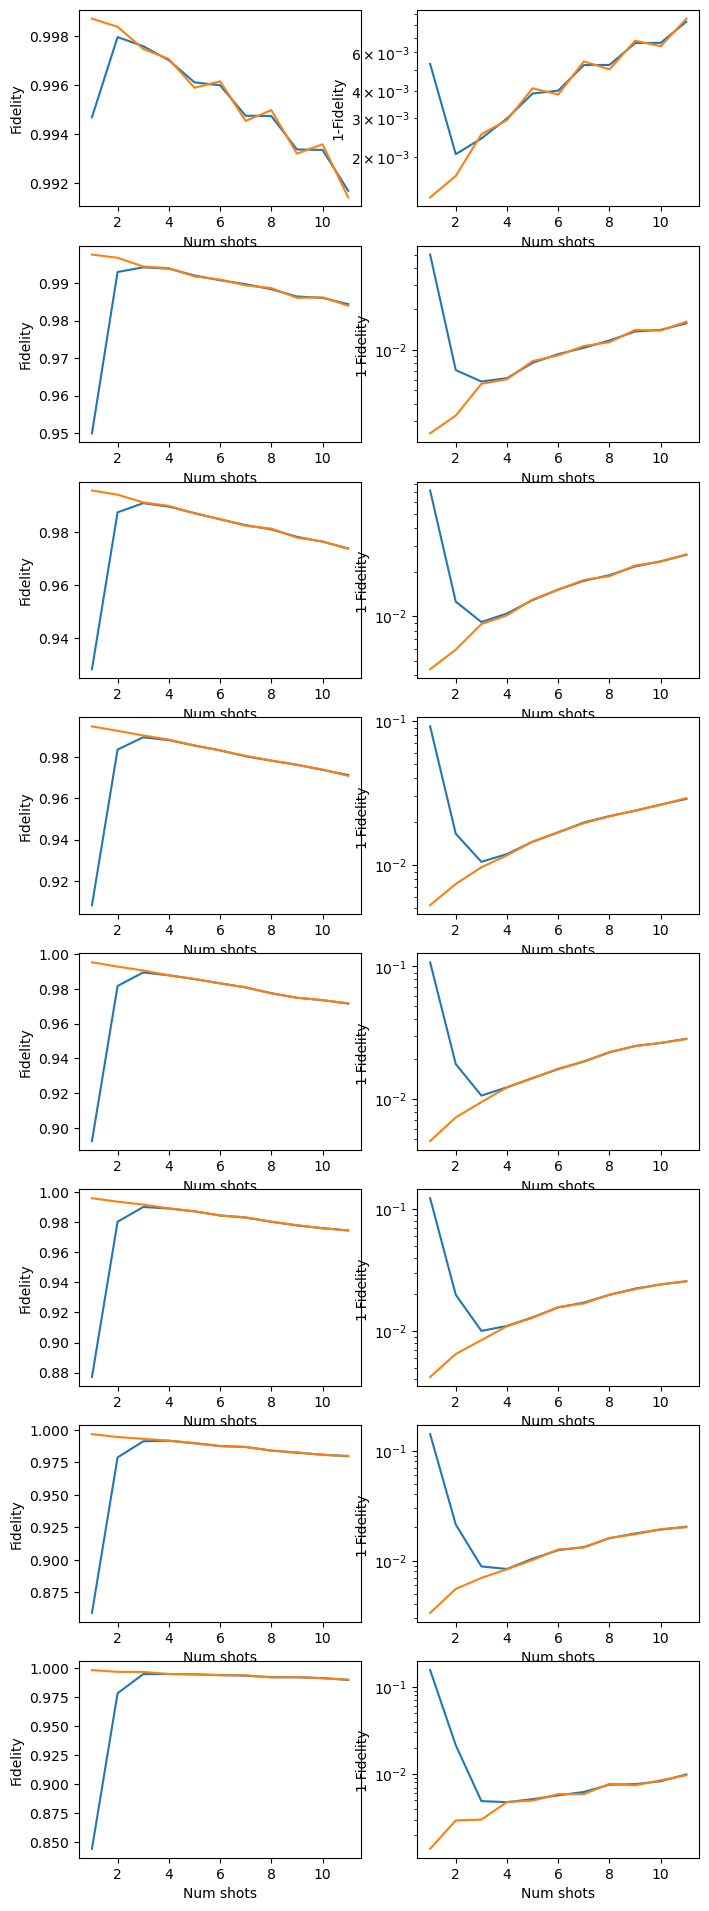

In [7]:
fig, ax = plt.subplots(8,2,figsize=(8,3*8))

for i in range(len(initial_state_array)):

    ax[i, 0].plot(n_shots_array, readout_fidelities[i])
    ax[i, 0].plot(n_shots_array, ionization_shock_fidelities[i])
    
    ax[i, 0].set_ylabel('Fidelity')
    ax[i, 0].set_xlabel('Num shots')
    
    ax[i, 1].plot(n_shots_array, 1-readout_fidelities[i])
    ax[i, 1].plot(n_shots_array, 1-ionization_shock_fidelities[i])
    
    ax[i, 1].set_yscale('log')
    
    ax[i, 1].set_ylabel('1-Fidelity')
    ax[i, 1].set_xlabel('Num shots')

Text(0.5, 0, 'Num shots')

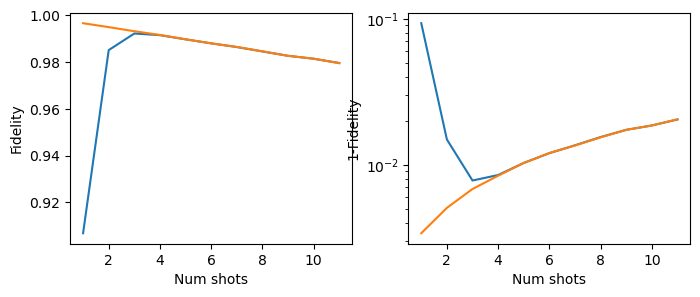

In [8]:
fig, ax = plt.subplots(1,2,figsize=(8,3))

ax[0].plot(n_shots_array, np.mean(readout_fidelities, axis=0))
ax[0].plot(n_shots_array, np.mean(ionization_shock_fidelities, axis=0))

ax[0].set_ylabel('Fidelity')
ax[0].set_xlabel('Num shots')

ax[1].plot(n_shots_array, 1-np.mean(readout_fidelities, axis=0))
ax[1].plot(n_shots_array, 1-np.mean(ionization_shock_fidelities, axis=0))

ax[1].set_yscale('log')

ax[1].set_ylabel('1-Fidelity')
ax[1].set_xlabel('Num shots')

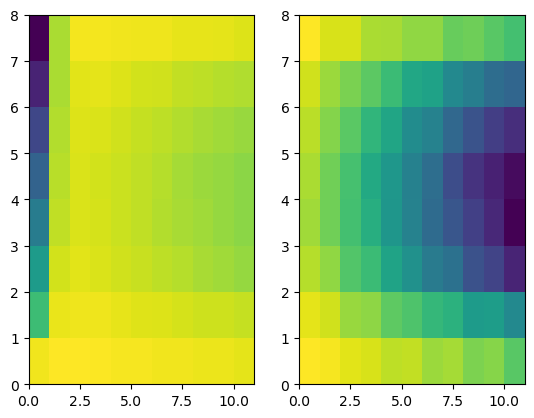

In [9]:
fig, ax = plt.subplots(1,2)
ax[0].pcolormesh(readout_fidelities)
ax[1].pcolormesh(ionization_shock_fidelities)

## compute readout trace vs. electron readout contrast

In [10]:
initial_state_array = np.arange(8)
n_shots_array = np.arange(1, 12)
repetitions = 50000

# confusion matrix
e_readout = np.linspace(0.8, 1.0, 10)
true_pos = e_readout + (1-e_readout)/2
false_pos = (1-e_readout)/2

readout_fidelities_array = np.zeros([len(e_readout), len(initial_state_array), len(n_shots_array)])
ionization_shock_fidelities_array = np.zeros([len(e_readout), len(initial_state_array), len(n_shots_array)])

for e in tqdm(range(len(e_readout))):
    for s in initial_state_array:
        for i, n_shots in enumerate((n_shots_array)):
            # true_states = compute_true_states(s, repetitions, n_shots)
            true_states = compute_true_states_with_readout_triggered_transitions(s, repetitions, n_shots, true_pos[e], false_pos[e], cdf_matrix)
            raw_traces = include_readout_errors(true_states, true_pos[e], false_pos[e])
            readout_trace = raw_traces.sum(axis=1)
            assigned_state = np.argmax(readout_trace, axis=1)
            readout_fidelity = np.sum(assigned_state == s) / repetitions
            readout_fidelities_array[e, s, i] = readout_fidelity
            
            raw_traces = include_readout_errors(true_states, true_pos=1, false_pos=0)
            readout_trace = raw_traces.sum(axis=1)
            assigned_state = np.argmax(readout_trace, axis=1)
            ionization_shock_fid = np.sum(assigned_state == s) / repetitions
            ionization_shock_fidelities_array[e, s, i] = ionization_shock_fid

100%|██████████| 10/10 [16:39<00:00, 99.91s/it]


In [13]:
n_shots_array

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

(0.56, 1.05)

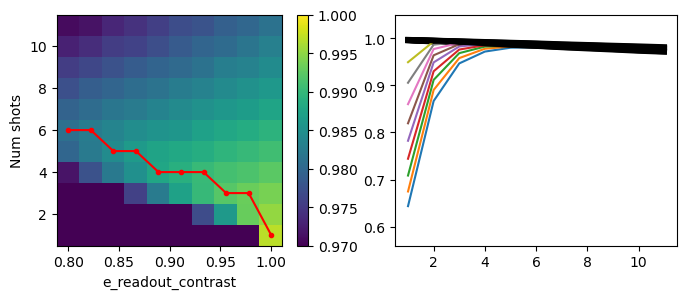

In [11]:
fig, ax = plt.subplots(1,2,figsize=(8,3))

avg_readout_fidelity = np.mean(readout_fidelities_array, axis=1).T

pcm = ax[0].pcolor(e_readout, n_shots_array, avg_readout_fidelity, vmin=0.97, vmax=1, shading='auto')
idx_max = np.argmax(np.mean(readout_fidelities_array, axis=1), axis=1)
ax[0].plot(e_readout, n_shots_array[idx_max],  color='r', marker='.')

plt.colorbar(pcm, ax=ax[0])
ax[0].set_xlabel('e_readout_contrast')
ax[0].set_ylabel('Num shots')

for i in range(len(e_readout)):
    ax[1].plot(n_shots_array, np.mean(readout_fidelities_array, axis=1)[i])
    ax[1].plot(n_shots_array, np.mean(ionization_shock_fidelities_array, axis=1)[i], color='k', lw=4)

ax[1].set_ylim(0.56, 1.05)



# ax[1].plot(n_shots_array, e_readout, 1-np.mean(readout_fidelities, axis=0))
# ax[1].plot(n_shots_array, e_readout, 1-np.mean(ionization_shock_fidelities, axis=0))

# ax[1].set_yscale('log')

# ax[1].set_ylabel('1-Fidelity')
# ax[1].set_xlabel('Num shots')

Text(0, 0.5, 'Repetition')

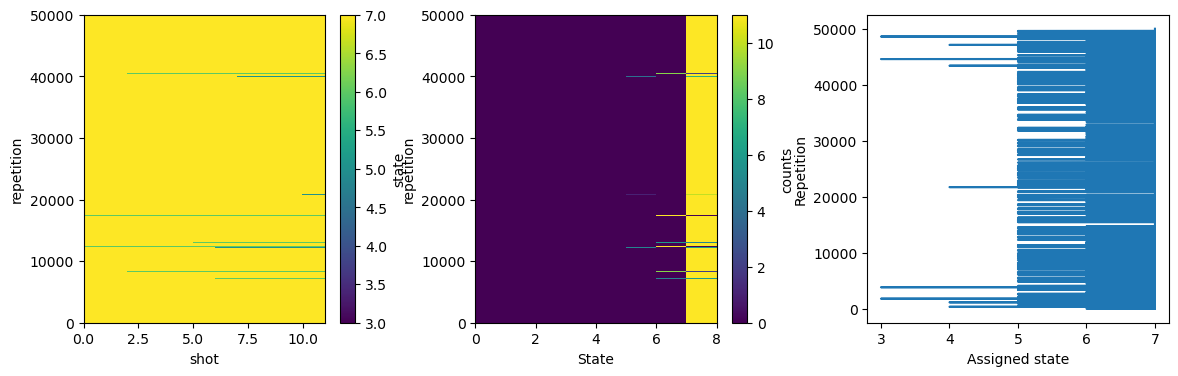

In [12]:
fig, ax = plt.subplots(1,3,figsize=(14,4), gridspec_kw = {'wspace':0.3})

pcm00 = ax[0].pcolor(true_states)
ax[0].set_xlabel('shot')
ax[0].set_ylabel('repetition')
plt.colorbar(pcm00, ax=ax[0], label='state')

pcm1 = ax[1].pcolor(readout_trace)
ax[1].set_xlabel('State')
ax[1].set_ylabel('repetition')
plt.colorbar(pcm1, ax=ax[1], label='counts')

ax[2].plot(assigned_state, np.arange(repetitions))
ax[2].set_xlabel('Assigned state')
ax[2].set_ylabel('Repetition')

## with reinitialization

# errorspace readout

In [19]:
# Inputs
initial_state = 4
repetitions = 10000
n_errorspace = 4
threshold = 2
true_pos = 0.968
false_pos = 0.019

# Simulate
confirmed, actual, transitions, traces = simulate_active_feedback_readout(
    initial_state,
    repetitions,
    n_errorspace,
    threshold,
    true_pos,
    false_pos,
    cdf_matrix
)

# Fidelity
fidelity = np.mean(confirmed == initial_state)

print(f"Readout fidelity: {fidelity:.4f}")

Readout fidelity: 0.9952


## loop over states

In [20]:
# Inputs
repetitions = 10000
n_errorspace = 4
threshold = 2
true_pos = 0.95
false_pos = 0.03

initial_states = np.arange(8)
errorspace_fidelities = np.zeros(len(initial_states))

# Simulate
for s in tqdm(initial_states):
    confirmed, actual, transitions, traces = simulate_active_feedback_readout(
        s,
        repetitions,
        n_errorspace,
        threshold,
        true_pos,
        false_pos,
        cdf_matrix
    )

    # Fidelity
    errorspace_fidelities[s] = np.mean(confirmed == s)

100%|██████████| 8/8 [00:10<00:00,  1.27s/it]


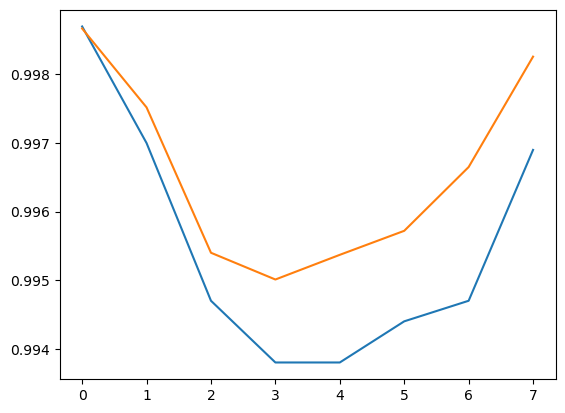

In [21]:
plt.plot(initial_states, errorspace_fidelities)
plt.plot(initial_states, ionization_shock_fidelities[:, 0])

## loop over errorspace shots

In [50]:
# Inputs
initial_state = 4
repetitions = 50000
n_errorspace_array = np.arange(1, 12)
threshold_array = np.ceil(n_errorspace_array/2)
true_pos = 0.968
false_pos = 0.03

initial_states = np.arange(8)
errorspace_fidelities = np.zeros([len(n_errorspace_array), len(initial_states)])
transition_array = np.zeros([len(n_errorspace_array), len(initial_states), repetitions])

# Simulate
for n in tqdm(range(len(n_errorspace_array))):
    for s in initial_states:
        confirmed, actual, transitions, traces = simulate_active_feedback_readout(
            s,
            repetitions,
            n_errorspace_array[n],
            threshold_array[n],
            true_pos,
            false_pos,
            cdf_matrix
        )

        # Fidelity
        errorspace_fidelities[n, s] = np.mean(confirmed == s)

        # Transitions
        transition_array[n, s] = transitions

100%|██████████| 11/11 [10:14<00:00, 55.88s/it]


In [35]:
time_esr = 200e-6
time_wait = 1e-3
time_ar = np.zeros(len(n_errorspace_array))
time_rr = np.zeros(len(n_errorspace_array))
for i in range(len(transition_array)):
    num_tries = transition_array[i].mean()
    print(num_tries)
    time_first_part = num_tries * 4 * (time_esr + time_wait)
    time_second_part = num_tries * (n_errorspace_array[i] * (7*time_esr + time_wait))
    time_ar[i] = time_first_part + time_second_part

    time_rr[i] = i*8*(time_esr + time_wait)

1.0964425
1.1196775
1.0788225
1.0805075
1.077415
1.0782425
1.0785275
1.07736
1.07779
1.07886
1.0779775


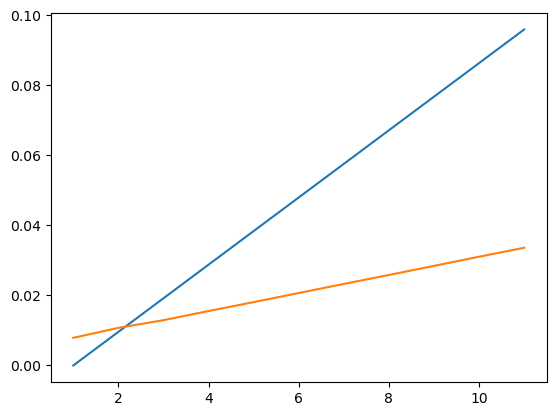

In [36]:
plt.plot(n_errorspace_array, time_rr)
plt.plot(n_errorspace_array, time_ar)

In [26]:
data = np.array([0.999425, 0.997775, 0.99615 , 0.994775, 0.994125, 0.994725,
       0.996425, 0.997925])

data_repeated = np.array([0.994, 0.9909, 0.9849, 0.9824, 0.9831, 0.9834, 0.9858, 0.9939])
n_errorspace_array = np.arange(1, 11, 1)

In [27]:
# errorspace_fidelities = np.load(r'sims_data/errorspace_fidelities.npy')
# ionization_shock_fidelities = np.load(r'sims_data/ionization_shock_fidelities.npy') 
# readout_fidelities = np.load(r'sims_data/readout_fidelities.npy')   
# initial_states = np.arange(8)

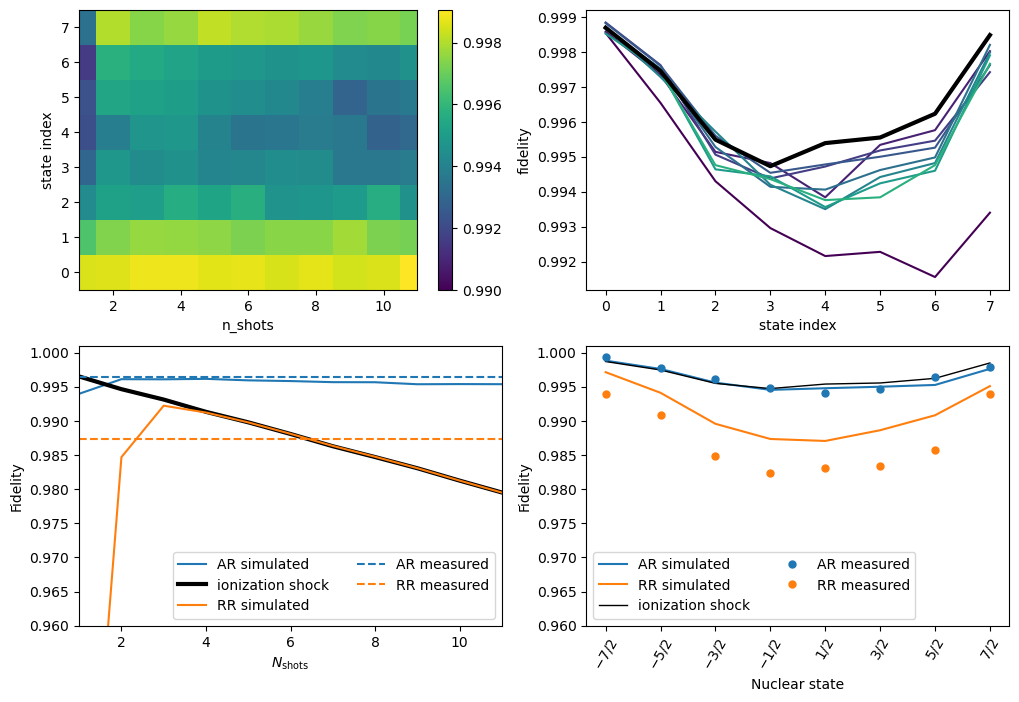

In [47]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

pcm = ax[0, 0].pcolormesh(n_errorspace_array, initial_states, errorspace_fidelities.T, shading='auto', vmin=0.99)
plt.colorbar(pcm, ax=ax[0, 0])

ax[0,0].set_xlabel('n_shots')
ax[0,0].set_ylabel('state index')


colors = plt.get_cmap('viridis')
n_shots_array = np.arange(1, 12)

for i in range(len(n_errorspace_array)-3):
    ax[0, 1].plot(initial_states, errorspace_fidelities[i], color=colors(i/len(n_errorspace_array)))

ax[0, 1].plot(initial_states, ionization_shock_fidelities[:, 0], color='k', lw=3)
ax[0, 1].set_xlabel('state index')
ax[0, 1].set_ylabel('fidelity')

ax[1, 0].plot(n_errorspace_array, errorspace_fidelities.mean(axis=1), label='AR simulated')
ax[1, 0].plot(n_shots_array, ionization_shock_fidelities.mean(axis=0), color='k', lw=3, label='ionization shock')
ax[1, 0].plot(n_shots_array, readout_fidelities.mean(axis=0), label='RR simulated')

ax[1, 0].axhline(data.mean(), ls='--', color='tab:blue', label='AR measured')
ax[1, 0].axhline(data_repeated.mean(), ls='--', color='tab:orange', label='RR measured')
ax[1, 0].set_xlabel(r'$N_{\rm shots}$')
ax[1, 0].set_ylabel('Fidelity')
ax[1, 0].legend(ncols=2)

ax[1, 0].set_ylim(0.96, 1.001)
ax[1, 0].set_xlim(1, 11)
ax[0, 0].set_xlim(1, 11)

ax[1, 1].set_ylim(0.96, 1.001)

ax[1, 1].plot(initial_states, errorspace_fidelities[3], label='AR simulated')
ax[1, 1].plot(initial_states, readout_fidelities[:, 3], label='RR simulated')
ax[1, 1].plot(initial_states, ionization_shock_fidelities[:, 0], color='k', lw=1, label='ionization shock')

ax[1, 1].plot(initial_states, data, label='AR measured', marker='.', ls='None', markersize=10, color='tab:blue')
ax[1,1].plot(initial_states, data_repeated, label='RR measured', marker='.', ls='None', markersize=10, color='tab:orange')

ax[1,1].set_xlabel('Nuclear state')
ax[1,1].set_ylabel('Fidelity')

ax[1,1].legend(ncols=2)

xticklabels = [r"$-7/2$", r"$-5/2$", r"$-3/2$", r"$-1/2$", 
          r"$1/2$", r"$3/2$", r"$5/2$", r"$7/2$"]

ax[1,1].set_xticks(np.arange(8), labels=xticklabels, rotation=60)

plt.savefig(r'comparison.png')

In [48]:
np.save('sims_data/ionization_shock.npy', ionization_shock_fidelities)
np.save('sims_data/errorspace_fidelities.npy', errorspace_fidelities)
np.save('sims_data/readout_fidelities.npy', readout_fidelities)

In [ ]:
rr_time = 8 * n_shots_array
ar_time = n_shots_array + 4

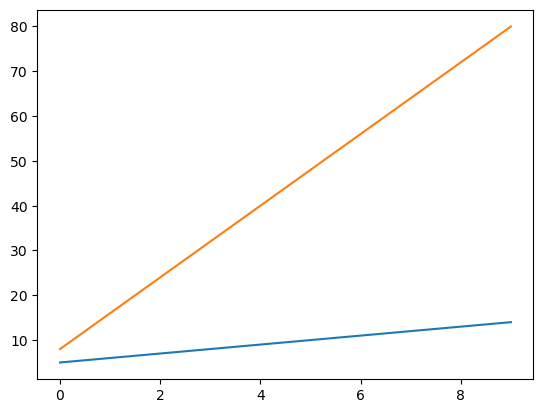

In [ ]:
plt.plot(ar_time)
plt.plot(rr_time)

## Loop over e_readout contrast

In [ ]:
avg_errorspace_fidelities.shape

(10, 10)

In [ ]:
avg_readout_fidelity.shape

(11, 10)

In [24]:
# Inputs
repetitions = 50000
n_errorspace_array = np.arange(1, 12)
threshold_array = np.ceil(n_errorspace_array/2)
e_readout = np.linspace(0.8, 1.0, 10)
true_pos = e_readout + (1-e_readout)/2
false_pos = (1-e_readout)/2

initial_states = np.arange(8)
errorspace_fidelities_array = np.zeros([len(e_readout), len(n_errorspace_array), len(initial_states)])
errorspace_transition_array = np.zeros([len(e_readout), len(n_errorspace_array), len(initial_states), repetitions])

# Simulate
for m in tqdm(range(len(e_readout))):
    for n in tqdm(range(len(n_errorspace_array))):
        for s in initial_states:
            confirmed, actual, transitions, traces = simulate_active_feedback_readout(
                s,
                repetitions,
                n_errorspace_array[n],
                threshold_array[n],
                true_pos[m],
                false_pos[m],
                cdf_matrix
            )
    
            # Fidelity
            errorspace_fidelities_array[m, n, s] = np.mean(confirmed == s)
    
            # Transitions
            errorspace_transition_array[m, n, s] = transitions

100%|██████████| 10/10 [1:54:01<00:00, 684.18s/it]


In [18]:
readout_fidelities_array.shape

(10, 8, 11)

In [19]:
n_shots_array

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [20]:
e_readout.shape

(10,)

In [21]:
readout_fidelities_array.shape

(10, 8, 11)

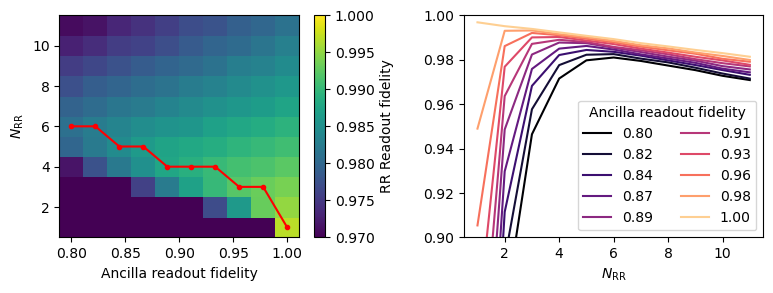

In [13]:
fig, ax = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35, 'left':0.06, 'bottom':0.14, 'right':0.94})

avg_readout_fidelity = np.mean(readout_fidelities_array, axis=1).T

pcm = ax[0].pcolor(e_readout, n_shots_array, avg_readout_fidelity, vmin=0.97, vmax=1, shading='auto')
idx_max = np.argmax(np.mean(readout_fidelities_array, axis=1), axis=1)
ax[0].plot(e_readout, n_shots_array[idx_max],  color='r', marker='.')

plt.colorbar(pcm, ax=ax[0], label='RR Readout fidelity')
ax[0].set_xlabel('Ancilla readout fidelity')
ax[0].set_ylabel(r'$N_{\rm RR}$')
colors = plt.get_cmap('magma')
for i in range(len(e_readout)):
    ax[1].plot(n_shots_array, np.mean(readout_fidelities_array, axis=1)[i], color=colors(i/len(e_readout)), label=f'{e_readout[i]:.2f}')
    # ax[1].plot(n_shots_array, np.mean(ionization_shock_fidelities_array, axis=1)[i], color='k', lw=4)
# ax[1].set_yscale('log')
ax[1].legend(ncols=2, title='Ancilla readout fidelity')
ax[1].set_ylim(0.9, 1.0)
ax[1].set_xlabel(r'$N_{\rm RR}$')

plt.savefig(r'raw_figs/repeated_readout_sim.pdf')

In [ ]:
errorspace_fidelities_array = np.load(r'sims_data/errorspace_fidelities_array.npy')
n_errorspace_array = np.arange(1, 12)


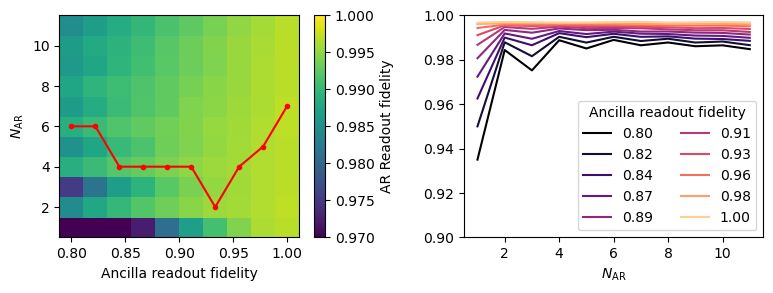

In [25]:
fig, ax = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35, 'left':0.06, 'bottom':0.14, 'right':0.94})

avg_errorspace_fidelities = np.mean(errorspace_fidelities_array, axis=2).T

pcm = ax[0].pcolor(e_readout, n_errorspace_array, avg_errorspace_fidelities, vmin=0.97, vmax=1, shading='auto')
idx_max = np.argmax(avg_errorspace_fidelities, axis=0)
ax[0].plot(e_readout, n_errorspace_array[idx_max],  color='r', marker='.')

plt.colorbar(pcm, ax=ax[0], label='AR Readout fidelity')
ax[0].set_xlabel('Ancilla readout fidelity')
ax[0].set_ylabel(r'$N_{\rm AR}$')

for i in range(len(e_readout)):
    ax[1].plot(n_errorspace_array, avg_errorspace_fidelities[:, i], color=colors(i/len(e_readout)), label=f'{e_readout[i]:.2f}')

ax[1].legend(ncols=2, title='Ancilla readout fidelity')
ax[1].set_ylim(0.9, 1.0)
ax[1].set_xlabel(r'$N_{\rm AR}$')

plt.savefig(r'raw_figs/adaptive_readout_sim.pdf')

In [19]:
avg_errorspace_fidelities[:, -1]

array([0.9967075, 0.9968375, 0.9969   , 0.9968125, 0.9969375, 0.9967875,
       0.9968625, 0.9969   , 0.996945 , 0.9968925, 0.9967025])

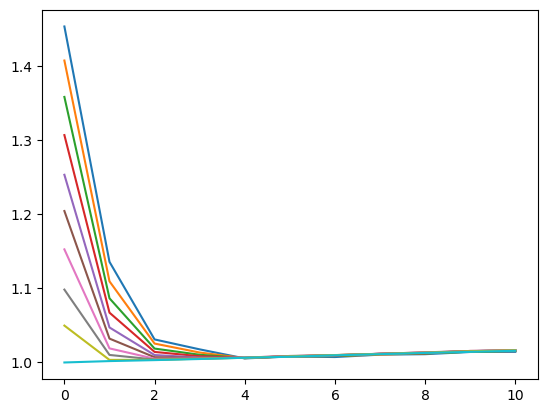

In [21]:
plt.plot(avg_errorspace_fidelities/avg_readout_fidelity)

In [28]:
# errorspace_transition_array = np.load(r'sims_data/errorspace_transition_array.npy')
num_tries = np.mean(np.mean(errorspace_transition_array, axis=-1), axis=-1)

In [33]:
num_tries.shape

(10, 11)

In [38]:
threshold_array

array([1., 1., 2., 2., 3., 3., 4., 4., 5., 5., 6.])

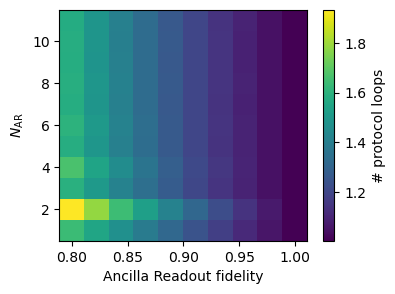

In [32]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

plt.pcolor(e_readout, n_errorspace_array, num_tries.T)
plt.colorbar(label='# protocol loops')
plt.xlabel(r'Ancilla Readout fidelity')
plt.ylabel(r'$N_{\rm AR}$')

plt.savefig(r'raw_figs/ionization_events.pdf', bbox_inches='tight')

In [ ]:
np.save(r'sims_data/errorspace_fidelities_array.npy', errorspace_fidelities_array)
np.save(r'sims_data/ionization_shock_fidelities_array.npy', ionization_shock_fidelities)
np.save(r'sims_data/readout_fidelities_array.npy', readout_fidelities_array)
np.save(r'sims_data/errorspace_transition_array.npy', transition_array)

In [31]:
np.save(r'sims_data/errorspace_transition_array.npy', errorspace_transition_array)